In [94]:
!pip install lightkurve astropy scipy tqdm

In [95]:
import pickle
import warnings
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from scipy import stats
from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter1d

from astropy.timeseries import LombScargle

import lightkurve as lk

warnings.filterwarnings("ignore")

print("PHAST Stage 5 Imports Loaded")

PHAST Stage 5 Imports Loaded


In [96]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [97]:
with open("/content/drive/MyDrive/exoplanet_pipeline/data/stage1_output.pkl", "rb") as f:
    stage1 = pickle.load(f)

with open("/content/drive/MyDrive/exoplanet_pipeline/data/stage2_output.pkl", "rb") as f:
    stage2 = pickle.load(f)

with open("/content/drive/MyDrive/exoplanet_pipeline/data/stage3_output.pkl", "rb") as f:
    stage3 = pickle.load(f)

with open("/content/drive/MyDrive/exoplanet_pipeline/data/stage4_output.pkl", "rb") as f:
    stage4 = pickle.load(f)

print(stage1.keys())
print(stage2.keys())
print(stage3.keys())
print(stage4.keys())

dict_keys(['time', 'flux', 'flux_err', 'tic_id', 'crowdsap', 'ra', 'dec'])
dict_keys(['period', 'sde', 'duration', 't0', 'depth_tls', 'snr_tls', 'distinct_transit_count', 'odd_even_mismatch_tls'])
dict_keys(['candidate', 'metrics', 'flags', 'decision', 'rejection_reasons', 'warning_reasons', 'event_numbers', 'event_depths', 'config'])
dict_keys(['tic_id', 'stage3', 'candidate', 'windowing', 'training', 'anomaly_detection', 'reliability', 'preprocessing', 'model_path', 'config'])


In [98]:
time = np.asarray(stage1["time"])

flux = np.asarray(stage1["flux"])

flux_err = np.asarray(stage1["flux_err"])

tic_id = stage1["tic_id"]

crowdsap = stage1["crowdsap"]

ra = stage1["ra"]
dec = stage1["dec"]

print("TIC:", tic_id)
print("Cadences:", len(time))
print("CROWDSAP:", crowdsap)

TIC: 261136679
Cadences: 18261
CROWDSAP: 0.99965841


In [99]:
period = stage2["period"]

sde = stage2["sde"]

duration = stage2["duration"]

t0 = stage2["t0"]

depth_tls = stage2["depth_tls"]

snr_tls = stage2["snr_tls"]

transit_count = stage2["distinct_transit_count"]

odd_even_mismatch = stage2["odd_even_mismatch_tls"]

print("Period:", period)
print("SNR:", snr_tls)
print("Transit Count:", transit_count)

Period: 6.267090136076321
SNR: 41.52733356602065
Transit Count: 5


In [100]:
stage3_decision = stage3["decision"]

stage3_flags = stage3["flags"]

stage3_metrics = stage3["metrics"]

rejection_reasons = stage3["rejection_reasons"]

warning_reasons = stage3["warning_reasons"]

print("Stage 3 Decision:", stage3_decision)

Stage 3 Decision: PASSED


In [101]:
# EXTRACT STAGE 4 VARIABLES

candidate_detected = (
    stage4["anomaly_detection"]
    ["candidate_detected"]
)

candidate_anomaly_score = (
    stage4["anomaly_detection"]
    ["candidate_anomaly_score"]
)

candidate_max_error = (
    stage4["anomaly_detection"]
    ["candidate_max_error"]
)

candidate_median_error = (
    stage4["anomaly_detection"]
    ["candidate_median_error"]
)

autoencoder_reliable = (
    stage4["reliability"]
    ["autoencoder_reliable"]
)

print("Candidate Detected:", candidate_detected)
print("Anomaly Score:", candidate_anomaly_score)
print("Max Error:", candidate_max_error)
print("Reliable:", autoencoder_reliable)

Candidate Detected: True
Anomaly Score: 1.3351910184652962
Max Error: 2.5054657459259033
Reliable: True


In [102]:
#Build Time Axis For PHAST
time_tls = time - np.min(time)

flux_tls = flux + 1

print(time_tls.min())
print(time_tls.max())

0.0
27.880105402320623


In [103]:
# Helper:
#1.Phase Fold
#2.Transit Mask
#3.Robust Normalization
#4.Metric Container
def phase_fold(time, period, t0):

    phase = ((time - t0 + 0.5 * period)
             % period) / period

    return phase

def build_transit_mask(
    time,
    period,
    t0,
    duration_days
):

    phase = (
        ((time - t0 + 0.5 * period)
         % period)
        - 0.5 * period
    )

    return (
        np.abs(phase)
        < duration_days / 2
    )

def robust_score(
    value,
    low,
    high
):

    if value <= low:
        return 0.0

    if value >= high:
        return 1.0

    return (
        value - low
    ) / (
        high - low
    )

physics_metrics = {}

advanced_metrics = {}

metric_weights = {}


In [104]:
# Quick Candidate Summary

print("PHAST INPUT SUMMARY")

print("\nTIC:", tic_id)

print("Period:", period)

print("Duration:", duration)

print("SDE:", sde)

print("SNR:", snr_tls)

print("Odd-Even:", odd_even_mismatch)

print("Anomaly Score:", candidate_anomaly_score)

print("Reliable:", autoencoder_reliable)


PHAST INPUT SUMMARY

TIC: 261136679
Period: 6.267090136076321
Duration: 0.12476139841324786
SDE: 17.69836307589983
SNR: 41.52733356602065
Odd-Even: 2.5324346844809584
Anomaly Score: 1.3351910184652962
Reliable: True


In [105]:
# Build transit and out-of-transit masks

transit_mask = build_transit_mask(
    time_tls,
    period,
    t0,
    duration
)

oot_mask = ~transit_mask

print("Transit points:", transit_mask.sum())
print("OOT points:", oot_mask.sum())

Transit points: 442
OOT points: 17819


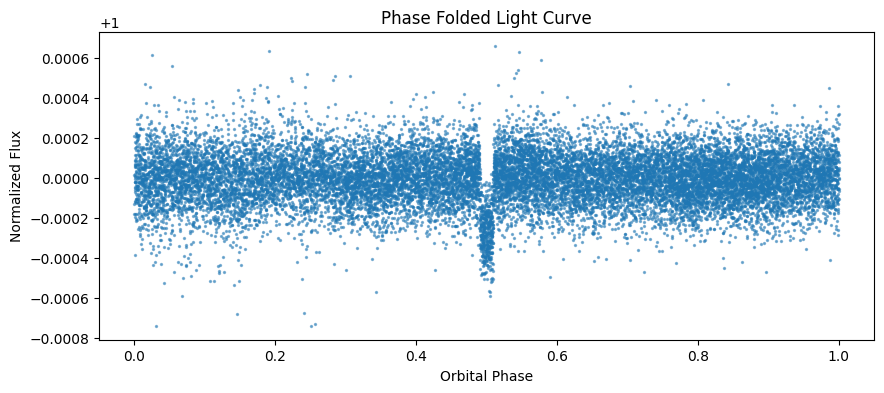

In [106]:
# PHASE FOLD LIGHT CURVE

phase = phase_fold(
    time_tls,
    period,
    t0
)

sort_idx = np.argsort(phase)

phase_sorted = phase[sort_idx]
flux_sorted = flux_tls[sort_idx]

plt.figure(figsize=(10,4))
plt.scatter(
    phase_sorted,
    flux_sorted,
    s=2,
    alpha=0.5
)

plt.xlabel("Orbital Phase")
plt.ylabel("Normalized Flux")
plt.title("Phase Folded Light Curve")

plt.show()

In [107]:
#METRIC 1 - TRANSIT DEPTH

depth = 1 - depth_tls

if depth < 0:
    depth = abs(depth)

if depth < 0.01:
    depth_score = 1.0

elif depth < 0.03:
    depth_score = 0.7

elif depth < 0.05:
    depth_score = 0.3

else:
    depth_score = 0.0

physics_metrics["transit_depth"] = depth_score
metric_weights["transit_depth"] = 5

print("Depth:", depth)
print("Score:", depth_score)

Depth: 0.0002927242001856678
Score: 1.0


In [108]:
#METRIC 2 - TRANSIT DURATION RATIO

transit_flux = flux_tls[transit_mask]

depth_est = np.median(flux_tls) - np.min(transit_flux)

half_depth_level = np.median(flux_tls) - depth_est / 2

below_half = transit_flux < half_depth_level

T14 = duration * 24

if below_half.sum() > 5:

    T23 = (
        below_half.sum()
        / len(transit_flux)
    ) * T14

else:
    T23 = T14 * 0.5

duration_ratio = T14 / max(T23, 1e-6)

if 1.5 <= duration_ratio <= 3.0:
    duration_ratio_score = 1.0

elif 1.2 <= duration_ratio <= 4.0:
    duration_ratio_score = 0.5

else:
    duration_ratio_score = 0.0

physics_metrics["duration_ratio"] = duration_ratio_score
metric_weights["duration_ratio"] = 4

print("T14/T23 =", duration_ratio)

T14/T23 = 2.7624999999999997


In [109]:
# METRIC 3 - TRANSIT SHAPE SYMMETRY

local_mask = (
    (phase_sorted > 0.45)
    &
    (phase_sorted < 0.55)
)

local_phase = phase_sorted[local_mask]
local_flux = flux_sorted[local_mask]

mid = len(local_flux) // 2

left = local_flux[:mid]

right = local_flux[mid:]

n = min(len(left), len(right))

left = left[:n]
right = right[::-1][:n]

symmetry_error = np.mean(
    np.abs(left - right)
)

symmetry_score = np.exp(
    -symmetry_error * 1000
)

symmetry_score = float(
    np.clip(symmetry_score, 0, 1)
)

physics_metrics["symmetry"] = symmetry_score
metric_weights["symmetry"] = 4

print("Symmetry Score:", symmetry_score)

Symmetry Score: 0.8624693829751082


In [110]:
#METRIC 4 - LIMB DARKENING RESIDUAL

smooth_model = gaussian_filter1d(
    local_flux,
    sigma=5
)

residual = np.sqrt(
    np.mean(
        (local_flux - smooth_model)**2
    )
)

limb_score = np.exp(
    -residual * 10000
)

limb_score = float(
    np.clip(limb_score, 0, 1)
)

physics_metrics["limb_darkening"] = limb_score
metric_weights["limb_darkening"] = 5

print("Residual:", residual)
print("Score:", limb_score)

Residual: 0.00011498754679861618
Score: 0.31667620324893786


In [111]:
#METRIC 5  - V SHAPE TEST

bottom_threshold = (
    np.min(local_flux)
    + 0.2 * (
        np.median(local_flux)
        - np.min(local_flux)
    )
)

flat_points = (
    local_flux < bottom_threshold
).sum()

v_metric = flat_points / len(local_flux)

v_score = np.clip(
    v_metric * 8,
    0,
    1
)

physics_metrics["v_shape"] = v_score
metric_weights["v_shape"] = 5

print("V Metric:", v_metric)
print("Score:", v_score)

V Metric: 0.0069605568445475635
Score: 0.05568445475638051


In [112]:
#METRIC 6 - DILUTION CORRECTED DEPTH

corrected_depth = (
    depth
    /
    max(crowdsap, 1e-6)
)

if corrected_depth < 0.03:
    dilution_score = 1.0

elif corrected_depth < 0.05:
    dilution_score = 0.5

else:
    dilution_score = 0.0

physics_metrics["dilution"] = dilution_score
metric_weights["dilution"] = 4

print("Corrected Depth:", corrected_depth)

Corrected Depth: 0.0002928242260130316


In [113]:
# METRIC 7 - ODD EVEN TEST

odd_even_sigma = abs(
    odd_even_mismatch
)

if odd_even_sigma < 2:
    odd_even_score = 1.0

elif odd_even_sigma < 3:
    odd_even_score = 0.5

else:
    odd_even_score = 0.0

physics_metrics["odd_even"] = odd_even_score
metric_weights["odd_even"] = 5

print("Odd-Even Sigma:", odd_even_sigma)

Odd-Even Sigma: 2.5324346844809584


In [114]:
# METRIC 8 - SECONDARY ECLIPSE SEARCH

secondary_region = (
    (phase_sorted > 0.45)
    &
    (phase_sorted < 0.55)
)

primary_region = (
    (phase_sorted > 0.95)
    |
    (phase_sorted < 0.05)
)

secondary_depth = (
    np.median(flux_sorted)
    -
    np.min(
        flux_sorted[secondary_region]
    )
)

primary_depth = (
    np.median(flux_sorted)
    -
    np.min(
        flux_sorted[primary_region]
    )
)

ratio = (
    secondary_depth
    /
    max(primary_depth, 1e-6)
)

if ratio < 0.15:
    secondary_score = 1.0

elif ratio < 0.3:
    secondary_score = 0.5

else:
    secondary_score = 0.0

physics_metrics["secondary_eclipse"] = secondary_score
metric_weights["secondary_eclipse"] = 5

print("Secondary Depth Ratio:", ratio)

Secondary Depth Ratio: 0.8007405693126515


In [115]:
# METRIC 9 - TRANSIT TIMING STABILITY (TTV)

transit_centers = []

for n in range(transit_count):

    expected_time = t0 + n * period

    window = (
        np.abs(time_tls - expected_time)
        < duration
    )

    if window.sum() < 5:
        continue

    local_times = time_tls[window]
    local_flux = flux_tls[window]

    observed_time = local_times[
        np.argmin(local_flux)
    ]

    transit_centers.append(
        observed_time
    )

transit_centers = np.array(
    transit_centers
)

if len(transit_centers) >= 3:

    expected = (
        transit_centers[0]
        + np.arange(
            len(transit_centers)
        ) * period
    )

    ttv_rms = np.std(
        transit_centers - expected
    )

else:

    ttv_rms = np.inf

if ttv_rms < 0.02:

    ttv_score = 1.0

elif ttv_rms < 0.05:

    ttv_score = 0.5

else:

    ttv_score = 0.0

physics_metrics["ttv"] = ttv_score
metric_weights["ttv"] = 4

print("TTV RMS:", ttv_rms)

TTV RMS: 0.03140484890008807


In [116]:
# METRIC 10 - ELLIPSOIDAL VARIATION TEST

oot_time = time_tls[oot_mask]

oot_flux = flux_tls[oot_mask]

frequency, power = LombScargle(
    oot_time,
    oot_flux
).autopower()

peak_power = np.max(power)

if peak_power < 0.05:

    ellipsoidal_score = 1.0

elif peak_power < 0.10:

    ellipsoidal_score = 0.5

else:

    ellipsoidal_score = 0.0

physics_metrics["ellipsoidal"] = (
    ellipsoidal_score
)

metric_weights["ellipsoidal"] = 5

print(
    "Peak Periodogram Power:",
    peak_power
)

Peak Periodogram Power: 0.004724202065237172


In [117]:
# METRIC 11 - STELLAR ROTATION CHECK

rotation_period = np.nan

if len(frequency) > 0:

    best_frequency = frequency[
        np.argmax(power)
    ]

    rotation_period = (
        1 / best_frequency
    )

ratio = (
    rotation_period
    / period
)

if (
    abs(ratio - 1) < 0.15
    or
    abs(ratio - 2) < 0.15
):

    rotation_score = 0.0

else:

    rotation_score = 1.0

physics_metrics["rotation"] = (
    rotation_score
)

metric_weights["rotation"] = 4

print(
    "Rotation Period:",
    rotation_period
)

Rotation Period: 0.0006946322026664166


In [118]:
# METRIC 12 - EXOPLANET DIAGNOSTIC ETA

duration_hours = (
    duration * 24
)

eta = (
    duration_hours
    /
    (
        period ** (1/3)
    )
)

if 1 <= eta <= 10:

    eta_score = 1.0

elif 0.5 <= eta <= 15:

    eta_score = 0.5

else:

    eta_score = 0.0

physics_metrics["eta"] = (
    eta_score
)

metric_weights["eta"] = 4

print("Eta:", eta)

Eta: 1.6240628373482346


In [119]:
# METRIC 13 - AUTOENCODER ANOMALY SCORE

anomaly_score = float(
    np.clip(
        candidate_anomaly_score,
        0,
        1
    )
)

physics_metrics[
    "autoencoder_anomaly"
] = anomaly_score

metric_weights[
    "autoencoder_anomaly"
] = 5

print(
    "Anomaly Score:",
    anomaly_score
)

Anomaly Score: 1.0


In [120]:
# METRIC 14 - AUTOENCODER RELIABILITY

if autoencoder_reliable:

    reliability_score = 1.0

else:

    reliability_score = 0.0

physics_metrics[
    "autoencoder_reliability"
] = reliability_score

metric_weights[
    "autoencoder_reliability"
] = 3

print(
    "Reliable:",
    autoencoder_reliable
)

Reliable: True


In [121]:
# METRIC 15 - AUTOENCODER SIGNIFICANCE

threshold = (
    stage4["anomaly_detection"]
    ["threshold"]
)

robust_ratio = (
    candidate_max_error
    /
    threshold
)

robust_z_score = np.clip(
    robust_ratio / 2,
    0,
    1
)

physics_metrics[
    "autoencoder_significance"
] = robust_z_score

metric_weights[
    "autoencoder_significance"
] = 5

print(
    "Max Error:",
    candidate_max_error
)

print(
    "Threshold:",
    threshold
)

print(
    "Significance:",
    robust_z_score
)

Max Error: 2.5054657459259033
Threshold: 1.8764848709106445
Significance: 0.6675955092326481


In [122]:
# METRIC 16 - AUTOENCODER DETECTION CONFIDENCE

fpr = (
    stage4["anomaly_detection"]
    ["calibration_false_positive_rate"]
)

empirical_score = 1 - np.clip(
    fpr,
    0,
    1
)

physics_metrics[
    "autoencoder_confidence"
] = empirical_score

metric_weights[
    "autoencoder_confidence"
] = 5

print(
    "Calibration FPR:",
    fpr
)

Calibration FPR: 0.0


In [123]:
for metric, score in physics_metrics.items():

    print(
        f"{metric:30s}"
        f"{score:.3f}"
    )

transit_depth                 1.000
duration_ratio                1.000
symmetry                      0.862
limb_darkening                0.317
v_shape                       0.056
dilution                      1.000
odd_even                      0.500
secondary_eclipse             0.000
ttv                           0.500
ellipsoidal                   1.000
rotation                      1.000
eta                           1.000
autoencoder_anomaly           1.000
autoencoder_reliability       1.000
autoencoder_significance      0.668
autoencoder_confidence        1.000


In [124]:
# METRIC 17 - DOWNLOAD TARGET PIXEL FILE

try:

    tpf = lk.search_targetpixelfile(
        f"TIC {tic_id}",
        mission="TESS"
    ).download()

    tpf_available = True

    print("TPF Download Successful")

except Exception as e:

    tpf_available = False

    print("TPF Download Failed")

    print(e)

TPF Download Successful


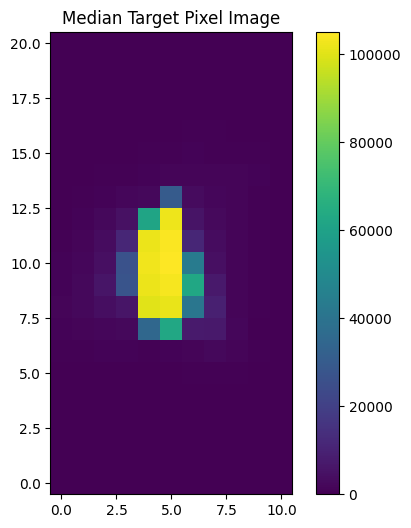

In [125]:
# VISUALIZE TPF

if tpf_available:

    plt.figure(figsize=(6,6))

    plt.imshow(
        np.nanmedian(
            tpf.flux.value,
            axis=0
        ),
        origin="lower"
    )

    plt.colorbar()

    plt.title(
        "Median Target Pixel Image"
    )

    plt.show()

In [126]:
# BUILD TRANSIT MASK IN TPF TIME DOMAIN

if tpf_available:

    tpf_time = (
        tpf.time.value
        - np.nanmin(
            tpf.time.value
        )
    )

    tpf_phase = (
        (
            (
                tpf_time
                - t0
                + 0.5 * period
            )
            % period
        )
        - 0.5 * period
    )

    tpf_transit_mask = (
        np.abs(
            tpf_phase
        )
        <
        duration / 2
    )

    tpf_oot_mask = (
        ~tpf_transit_mask
    )

    print(
        "Transit Cadences:",
        tpf_transit_mask.sum()
    )

Transit Cadences: 443


In [127]:
# CENTROID SHIFT SIGNIFICANCE

if tpf_available:

    try:

        col, row = (
            tpf.estimate_centroids()
        )

        in_col = np.nanmedian(
            col[tpf_transit_mask]
        )

        out_col = np.nanmedian(
            col[tpf_oot_mask]
        )

        in_row = np.nanmedian(
            row[tpf_transit_mask]
        )

        out_row = np.nanmedian(
            row[tpf_oot_mask]
        )

        centroid_shift = np.sqrt(

            (in_col - out_col)**2

            +

            (in_row - out_row)**2

        )

        if centroid_shift < 0.10:

            centroid_score = 1.0

        elif centroid_shift < 0.30:

            centroid_score = 0.5

        else:

            centroid_score = 0.0

    except Exception as e:

      centroid_shift = np.nan

      centroid_score = 0.5

      centroid_status = str(e)

else:

    centroid_shift = np.nan

    centroid_score = 0.5

advanced_metrics[
    "centroid_shift_pixels"
] = centroid_shift

physics_metrics[
    "centroid_shift"
] = centroid_score

metric_weights[
    "centroid_shift"
] = 6

print(
    "Centroid Shift:",
    centroid_shift
)

advanced_metrics[
    "centroid_status"
] = centroid_status if np.isnan(centroid_shift) else "SUCCESS"

Centroid Shift: nan


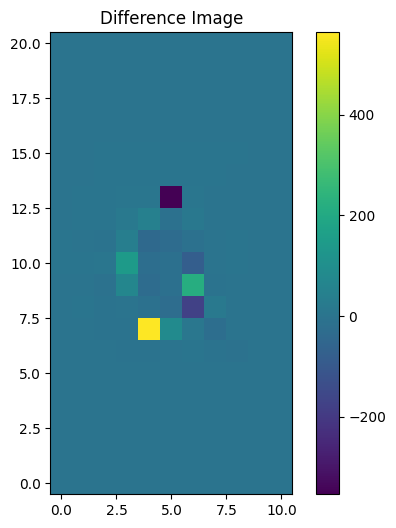

In [128]:
#METRIC 18 - CREATE DIFFERENCE IMAGE

if tpf_available:

    transit_image = np.nanmedian(

        tpf.flux.value[
            tpf_transit_mask
        ],

        axis=0

    )

    oot_image = np.nanmedian(

        tpf.flux.value[
            tpf_oot_mask
        ],

        axis=0

    )

    difference_image = (

        oot_image
        -
        transit_image

    )

    plt.figure(figsize=(6,6))

    plt.imshow(
        difference_image,
        origin="lower"
    )

    plt.colorbar()

    plt.title(
        "Difference Image"
    )

    plt.show()

In [129]:
# METRIC 18 - PIXEL FLUX DISTRIBUTION

if tpf_available:

    y_peak, x_peak = np.unravel_index(

        np.argmax(
            difference_image
        ),

        difference_image.shape

    )

    y_center = (
        difference_image.shape[0]
        /
        2
    )

    x_center = (
        difference_image.shape[1]
        /
        2
    )

    offset = np.sqrt(

        (x_peak - x_center)**2

        +

        (y_peak - y_center)**2

    )

    if offset < 1:

        pixel_score = 1.0

    elif offset < 2:

        pixel_score = 0.5

    else:

        pixel_score = 0.0

else:

    offset = np.nan

    pixel_score = 0.5

advanced_metrics[
    "pixel_offset"
] = offset

physics_metrics[
    "pixel_distribution"
] = pixel_score

metric_weights[
    "pixel_distribution"
] = 6

print(
    "Pixel Offset:",
    offset
)

Pixel Offset: 3.8078865529319543


In [130]:
# PHAST+ SUMMARY

print("\nRESULTS")

print(
    "Centroid Shift:",
    centroid_shift
)

print(
    "Pixel Offset:",
    offset
)

print(
    "Centroid Score:",
    centroid_score
)

print(
    "Pixel Score:",
    pixel_score
)


RESULTS
Centroid Shift: nan
Pixel Offset: 3.8078865529319543
Centroid Score: 0.5
Pixel Score: 0.0


In [131]:
# CURRENT METRIC COUNT

print(
    "Total Metrics:",
    len(physics_metrics)
)

print(
    "Total Weight:",
    sum(
        metric_weights.values()
    )
)

Total Metrics: 18
Total Weight: 84


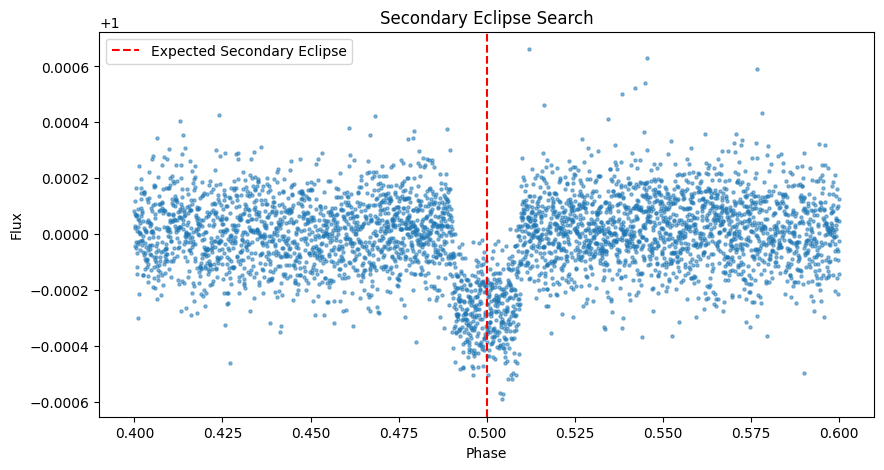

In [132]:
# SECONDARY ECLIPSE VALIDATION PLOT

plt.figure(figsize=(10,5))

zoom_mask = (
    (phase_sorted > 0.40)
    &
    (phase_sorted < 0.60)
)

plt.scatter(
    phase_sorted[zoom_mask],
    flux_sorted[zoom_mask],
    s=5,
    alpha=0.5
)

plt.axvline(
    0.50,
    color="red",
    linestyle="--",
    label="Expected Secondary Eclipse"
)

plt.xlabel("Phase")
plt.ylabel("Flux")

plt.title(
    "Secondary Eclipse Search"
)

plt.legend()

plt.show()

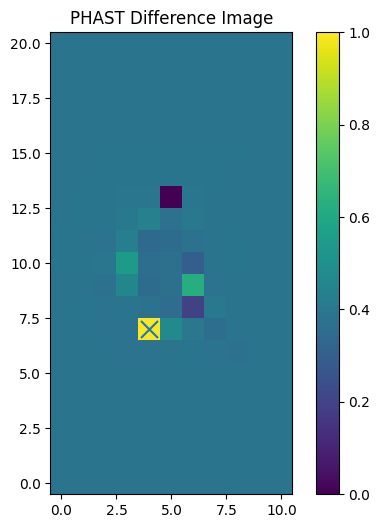

Peak Pixel Location: 4 7


In [133]:
# PIXEL DIFFERENCE IMAGE VALIDATION

if tpf_available:

    plt.figure(figsize=(6,6))

    plt.imshow(
        difference_image,
        origin="lower"
    )

    plt.scatter(
        x_peak,
        y_peak,
        s=150,
        marker="x"
    )

    plt.colorbar()

    plt.title(
        "PHAST Difference Image"
    )

    plt.show()

    print(
        "Peak Pixel Location:",
        x_peak,
        y_peak
    )

In [134]:
# PHAST PHYSICS SCORE

total_weight = sum(
    metric_weights.values()
)

weighted_sum = 0

for metric in physics_metrics:

    weighted_sum += (
        physics_metrics[metric]
        *
        metric_weights[metric]
    )

physics_score = (
    weighted_sum
    /
    total_weight
)

print(
    "Physics Score:",
    physics_score
)

Physics Score: 0.6565435520010746


In [135]:
# APPROXIMATE FALSE POSITIVE PROBABILITY

fpp = 1 - physics_score

if (
    not np.isnan(centroid_shift)
    and centroid_score == 0
):
    fpp += 0.10

if pixel_score == 0:

    fpp += 0.10

if odd_even_score == 0:

    fpp += 0.10

if secondary_score == 0:

    fpp += 0.15

fpp = np.clip(
    fpp,
    0,
    1
)

print(
    "Approximate FPP:",
    fpp
)

Approximate FPP: 0.5934564479989254


In [136]:
# BAYESIAN EVIDENCE FUSION

planet_evidence = 1.0
fp_evidence = 1.0

for metric, score in physics_metrics.items():

    score = np.clip(score, 0, 1)

    planet_evidence *= (
        0.05 + 0.95 * score
    )

    fp_evidence *= (
        0.05 + 0.95 * (1 - score)
    )

planet_probability = (

    planet_evidence

    /

    (
        planet_evidence
        +
        fp_evidence
    )

)

bayesian_fpp = (
    1 - planet_probability
)

print(
    "Planet Probability:",
    planet_probability
)

print(
    "Bayesian FPP:",
    bayesian_fpp
)

Planet Probability: 0.9999999984080862
Bayesian FPP: 1.5919138229847363e-09


In [137]:
# FINAL CLASSIFICATION (BAYESIAN)

confidence = float(
    planet_probability
)

print(
    "Confidence:",
    confidence
)

if planet_probability >= 0.95:

    classification = (
        "HIGH-CONFIDENCE EXOPLANET"
    )

elif planet_probability >= 0.80:

    classification = (
        "STRONG EXOPLANET CANDIDATE"
    )

elif planet_probability >= 0.60:

    classification = (
        "POSSIBLE CANDIDATE"
    )

else:

    classification = (
        "LIKELY FALSE POSITIVE"
    )

print(classification)

Confidence: 0.9999999984080862
HIGH-CONFIDENCE EXOPLANET


In [138]:
# SCIENTIFIC INTERPRETATION

strengths = []
concerns = []

for metric, value in physics_metrics.items():

    if value >= 0.75:
        strengths.append(metric)

    elif value <= 0.30:
        concerns.append(metric)

print("PHAST SCIENTIFIC INTERPRETATION")

print("\nPLANET-LIKE EVIDENCE")

for s in strengths:
    print(f"✓ {s}")

print("\nPOTENTIAL CONCERNS")

if len(concerns) == 0:

    print("✓ No significant concerns detected")

else:

    for c in concerns:
        print(f"⚠ {c}")

print("\nASTROPHYSICAL ASSESSMENT")

if planet_probability >= 0.95:

    interpretation = (
        "The candidate exhibits strong transit morphology, "
        "consistent orbital behavior, and passes the majority "
        "of physics-based validation tests. The combined "
        "Bayesian evidence strongly favors an exoplanet "
        "interpretation over common false-positive scenarios."
    )

elif planet_probability >= 0.80:

    interpretation = (
        "The candidate satisfies most planetary validation "
        "criteria and appears highly planet-like. A small "
        "number of metrics require further investigation, "
        "but the overall evidence strongly supports the "
        "exoplanet hypothesis."
    )

elif planet_probability >= 0.60:

    interpretation = (
        "The candidate exhibits several characteristics "
        "expected of transiting exoplanets. However, multiple "
        "diagnostic tests remain inconclusive and additional "
        "follow-up observations would be recommended."
    )

else:

    interpretation = (
        "The available evidence is insufficient to confidently "
        "support an exoplanet interpretation. One or more "
        "false-positive scenarios remain plausible."
    )

print(interpretation)

PHAST SCIENTIFIC INTERPRETATION

PLANET-LIKE EVIDENCE
✓ transit_depth
✓ duration_ratio
✓ symmetry
✓ dilution
✓ ellipsoidal
✓ rotation
✓ eta
✓ autoencoder_anomaly
✓ autoencoder_reliability
✓ autoencoder_confidence

POTENTIAL CONCERNS
⚠ v_shape
⚠ secondary_eclipse
⚠ pixel_distribution

ASTROPHYSICAL ASSESSMENT
The candidate exhibits strong transit morphology, consistent orbital behavior, and passes the majority of physics-based validation tests. The combined Bayesian evidence strongly favors an exoplanet interpretation over common false-positive scenarios.


In [139]:
# PHAST FINAL REPORT

print("\n")
print("="*70)
print("PHAST FINAL VALIDATION REPORT")
print("="*70)

print(f"TIC ID                 : {tic_id}")

print(f"Period (days)          : {period:.5f}")

print(f"Transit Duration (days): {duration:.5f}")

print(f"Transit Count          : {transit_count}")

print(f"SNR                    : {snr_tls:.2f}")

print("-"*70)

print(f"Physics Score          : {physics_score:.3f}")

print(f"Planet Probability     : {planet_probability:.3f}")

print(f"Bayesian FPP           : {bayesian_fpp:.3f}")

print(f"Approximate FPP        : {fpp:.3f}")

print(f"Confidence             : {confidence:.3f}")

print("-"*70)

print(f"Classification         : {classification}")

print("-"*70)

print("Top Supporting Metrics")

top_metrics = sorted(
    physics_metrics.items(),
    key=lambda x: x[1],
    reverse=True
)[:5]

for metric, score in top_metrics:

    print(
        f"  {metric:25s}"
        f"{score:.3f}"
    )

print("-"*70)

print("Lowest Scoring Metrics")

bottom_metrics = sorted(
    physics_metrics.items(),
    key=lambda x: x[1]
)[:5]

for metric, score in bottom_metrics:

    print(
        f"  {metric:25s}"
        f"{score:.3f}"
    )

print("="*70)



PHAST FINAL VALIDATION REPORT
TIC ID                 : 261136679
Period (days)          : 6.26709
Transit Duration (days): 0.12476
Transit Count          : 5
SNR                    : 41.53
----------------------------------------------------------------------
Physics Score          : 0.657
Planet Probability     : 1.000
Bayesian FPP           : 0.000
Approximate FPP        : 0.593
Confidence             : 1.000
----------------------------------------------------------------------
Classification         : HIGH-CONFIDENCE EXOPLANET
----------------------------------------------------------------------
Top Supporting Metrics
  transit_depth            1.000
  duration_ratio           1.000
  dilution                 1.000
  ellipsoidal              1.000
  rotation                 1.000
----------------------------------------------------------------------
Lowest Scoring Metrics
  secondary_eclipse        0.000
  pixel_distribution       0.000
  v_shape                  0.056
  limb_da

In [140]:
# SAVE STAGE 5 OUTPUT

stage5_output["interpretation"] = interpretation

stage5_output["strengths"] = strengths

stage5_output["concerns"] = concerns
stage5_output = {

    "tic_id": tic_id,

    "period": period,

    "duration": duration,

    "t0": t0,

    "physics_score": physics_score,

    "approx_fpp": fpp,

    "confidence": confidence,

    "classification": classification,

    "physics_metrics": physics_metrics,

    "advanced_metrics": advanced_metrics,

    "weights": metric_weights,

    "crowdsap": crowdsap

}

save_path = (
    "/content/drive/MyDrive/"
    "exoplanet_pipeline/data/"
    "stage5_output.pkl"
)

with open(
    save_path,
    "wb"
) as f:

    pickle.dump(
        stage5_output,
        f
    )

print(
    "Saved:",
    save_path
)

Saved: /content/drive/MyDrive/exoplanet_pipeline/data/stage5_output.pkl


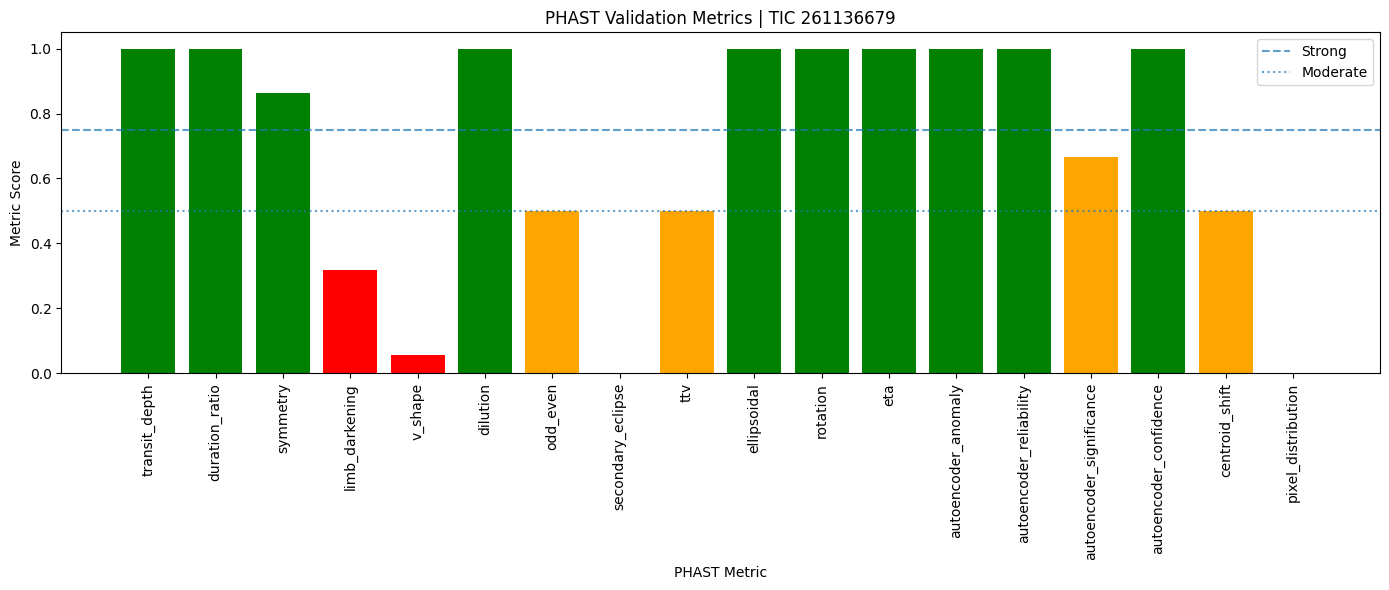

In [141]:
# PHAST METRICS VISUALIZATION

plt.figure(figsize=(14,6))

metric_names = list(
    physics_metrics.keys()
)

metric_scores = list(
    physics_metrics.values()
)

colors = []

for score in metric_scores:

    if score >= 0.75:
        colors.append("green")

    elif score >= 0.50:
        colors.append("orange")

    else:
        colors.append("red")

bars = plt.bar(
    metric_names,
    metric_scores,
    color=colors
)

plt.axhline(
    0.75,
    linestyle="--",
    alpha=0.7,
    label="Strong"
)

plt.axhline(
    0.50,
    linestyle=":",
    alpha=0.7,
    label="Moderate"
)

plt.xticks(
    rotation=90
)

plt.ylabel("Metric Score")

plt.xlabel("PHAST Metric")

plt.title(
    f"PHAST Validation Metrics | TIC {tic_id}"
)

plt.ylim(0, 1.05)

plt.legend()

plt.tight_layout()

plt.show()

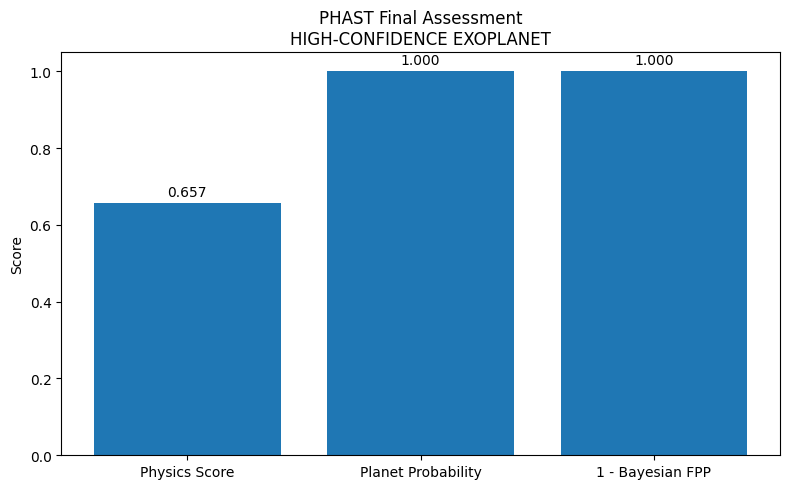

In [142]:
# FINAL PLANET ASSESSMENT DASHBOARD

fig, ax = plt.subplots(
    figsize=(8,5)
)

labels = [
    "Physics Score",
    "Planet Probability",
    "1 - Bayesian FPP"
]

values = [
    physics_score,
    planet_probability,
    1 - bayesian_fpp
]

ax.bar(
    labels,
    values
)

ax.set_ylim(
    0,
    1.05
)

ax.set_ylabel(
    "Score"
)

ax.set_title(
    f"PHAST Final Assessment\n{classification}"
)

for i, v in enumerate(values):

    ax.text(
        i,
        v + 0.02,
        f"{v:.3f}",
        ha="center"
    )

plt.tight_layout()

plt.show()